# ReadmitWatch: An End-to-End Pandas Project for Hospital Readmission Analytics

This notebook applies every technique from **Chapter 3 ("Data Manipulation
with Pandas") of the *Python Data Science Handbook*** to a real, high-stakes
problem in healthcare operations: **unplanned 30-day hospital readmissions**.

> **Data note:** every patient, admission, and clinical value in this
> notebook is **synthetically generated** — there is no real patient data
> here, and nothing in this notebook is clinical advice or a validated
> clinical tool. The *pipeline itself*, however, mirrors how a real hospital
> quality-analytics team would work with real (HIPAA-protected) EHR extracts.

### The problem

A 30-day readmission is when a patient is discharged and then admitted again
to any hospital within 30 days. It matters because:

- The U.S. Centers for Medicare & Medicaid Services (CMS) runs the
  **Hospital Readmissions Reduction Program (HRRP)**, which financially
  penalizes hospitals with excess readmission rates for certain conditions
  (heart failure, COPD, pneumonia, hip/knee replacement, and more).
- Readmissions are also a direct signal of care-transition failures: missed
  follow-ups, medication issues, and inadequate discharge planning.
- Every avoided readmission is both a better patient outcome and meaningful
  avoided cost.

### The scenario

You're a data analyst on the quality-analytics team at **Meridian General**,
a mid-size hospital. You need to build the pipeline that turns four messy,
independently-sourced extracts into a single readmission-analytics table,
then use it to answer the questions leadership is asking before the next
HRRP reporting cycle.

| Source | Description |
|---|---|
| **Patient registry** | Demographics & chronic-condition burden, one row per patient |
| **Admissions log** | Every inpatient stay: dates, unit, diagnosis, physician (arrives as 4 quarterly extracts) |
| **Bedside vitals telemetry** | Hourly vitals during selected stays (has sensor dropouts) |
| **Lab results** | Point-in-time lab draws during each stay (has missing values) |
| **Billing / claims** | Charges and payer detail per admission |
| **Discharge summaries** | Free-text discharge notes (messy, inconsistent formatting) |

### What this notebook covers, mapped to the handbook

1. **3.01** — Pandas objects: `Series`, `DataFrame`, `Index`
2. **3.02** — Data indexing & selection (`loc`, `iloc`, boolean masks)
3. **3.03** — Operations in Pandas: ufuncs & index alignment
4. **3.04** — Missing values (`isnull`, `dropna`, `fillna`, interpolation)
5. **3.05** — Hierarchical indexing (`MultiIndex`, `stack`/`unstack`)
6. **3.06** — Combining datasets: `concat`
7. **3.07** — Combining datasets: `merge` & `join`
8. **3.08** — Aggregation and grouping (`groupby`, `agg`, `transform`, `filter`)
9. **3.09** — Pivot tables
10. **3.10** — Vectorized string operations
11. **3.11** — Working with time series — **this is where we actually
    compute the 30-day readmission outcome itself**, plus early-warning
    vitals trends
12. **3.12** — High-performance Pandas: `eval()` and `query()`
13. **3.13** — Wrap-up: findings and next steps

By the end we'll have a clean, merged, readmission-labeled analytics table
and concrete, ranked findings: which units, diagnoses, and payer groups
drive the readmission rate, which discharge-note risk factors correlate
with return visits, and where a real care-transition intervention would
have the most leverage.


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(7)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)

print("pandas:", pd.__version__)
print("numpy :", np.__version__)


pandas: 3.0.2
numpy : 2.4.4


## 0. Building the raw ReadmitWatch data (synthetic)

Real EHR extracts come from the ADT (admit-discharge-transfer) feed, the lab
system, bedside monitors, the billing system, and dictated/typed discharge
notes — each with its own quirks. We reproduce that same messiness here so
every later section works exactly as it would on a real extract.


In [2]:
# ---------------------------------------------------------------
# 1) PATIENT REGISTRY (static demographics, one row per patient)
# ---------------------------------------------------------------
n_patients = 600
patient_ids = [f"PT{str(i).zfill(5)}" for i in range(1, n_patients + 1)]

insurance_types = rng.choice(
    ["Medicare", "Medicaid", "Private", "Uninsured"],
    size=n_patients, p=[0.42, 0.20, 0.32, 0.06],
)
age = np.clip(rng.normal(58, 18, n_patients), 18, 95).round().astype(int)
# Older / Medicare patients tend to carry more chronic conditions -- realistic correlation
chronic_base = (age > 65).astype(int) + (insurance_types == "Medicaid").astype(int)
n_chronic = np.clip(rng.poisson(0.8 + chronic_base), 0, 6)

patients = pd.DataFrame({
    "patient_id": patient_ids,
    "age": age,
    "sex": rng.choice(["F", "M"], n_patients),
    "insurance_type": insurance_types,
    "n_chronic_conditions": n_chronic,
    "lives_alone": rng.choice([True, False], n_patients, p=[0.28, 0.72]),
}).set_index("patient_id")
patients.head()


,age,sex,insurance_type,n_chronic_conditions,lives_alone
patient_id,,,,,
PT00001,65,M,Private,3,False
PT00002,60,M,Private,2,False
PT00003,76,F,Private,0,False
PT00004,44,F,Medicare,1,True
PT00005,57,F,Medicare,0,True


In [3]:
# ---------------------------------------------------------------
# 2) ADMISSIONS LOG -- built as 4 quarterly extracts (so 3.06/concat has
#    real work to do), including deliberate READMISSIONS (same patient,
#    multiple stays, some within 30 days of a prior discharge).
# ---------------------------------------------------------------
units = ["Cardiology", "General Medicine", "ICU", "Orthopedics", "Pulmonology"]
diagnoses = {
    "Cardiology": ["Heart Failure", "Atrial Fibrillation", "Myocardial Infarction"],
    "General Medicine": ["Sepsis", "UTI", "Diabetes Complication", "Dehydration"],
    "ICU": ["Sepsis", "Respiratory Failure", "Post-Surgical Complication"],
    "Orthopedics": ["Hip Fracture", "Elective Knee Replacement", "Spinal Fusion"],
    "Pulmonology": ["COPD Exacerbation", "Pneumonia", "Asthma Exacerbation"],
}
physicians = [f"DR{str(i).zfill(3)}" for i in range(1, 19)]

quarter_bounds = [
    ("2024-01-01", "2024-04-01"),
    ("2024-04-01", "2024-07-01"),
    ("2024-07-01", "2024-10-01"),
    ("2024-10-01", "2025-01-01"),
]

def random_dates(start, end, n):
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    span = (end_ts - start_ts).days
    offsets = rng.integers(0, span, n)
    return start_ts + pd.to_timedelta(offsets, unit="D")

# We generate admissions patient-by-patient across the whole year so that
# readmission linkages are realistic, THEN split the result into the four
# quarterly extracts a real ADT export would arrive as.
all_admissions = []
admit_counter = 1
for pid in patient_ids:
    # base admission count, boosted for higher chronic-condition patients
    n_stays = rng.poisson(0.55 + 0.25 * patients.loc[pid, "n_chronic_conditions"])
    n_stays = min(n_stays, 4)
    if n_stays == 0:
        continue
    unit = rng.choice(units)
    dx_pool = diagnoses[unit]
    cur_date = pd.Timestamp("2024-01-01") + pd.to_timedelta(rng.integers(0, 300), unit="D")
    for s in range(n_stays):
        los_days = max(1, int(rng.gamma(2.2, 1.8)))
        admit_date = cur_date
        discharge_date = admit_date + pd.Timedelta(days=los_days)
        # 22% chance the NEXT stay for this patient is a true early readmission
        if s < n_stays - 1:
            if rng.random() < 0.22:
                gap = rng.integers(3, 29)          # readmission within 30 days
            else:
                gap = rng.integers(31, 150)        # unrelated later stay
            cur_date = discharge_date + pd.Timedelta(days=int(gap))

        all_admissions.append({
            "admission_id": f"A{str(admit_counter).zfill(6)}",
            "patient_id": pid,
            "admit_date": admit_date,
            "discharge_date": discharge_date,
            "unit": unit,
            "primary_diagnosis": rng.choice(dx_pool),
            "attending_id": rng.choice(physicians),
        })
        admit_counter += 1

admissions_all = pd.DataFrame(all_admissions)
admissions_all = admissions_all[admissions_all["admit_date"] < "2025-01-01"].reset_index(drop=True)

# Split into 4 quarterly extracts by admit_date, mimicking 4 separate ADT pulls
quarterly_frames = []
for start, end in quarter_bounds:
    qf = admissions_all[(admissions_all["admit_date"] >= start) &
                         (admissions_all["admit_date"] < end)].reset_index(drop=True)
    quarterly_frames.append(qf)

print([f.shape for f in quarterly_frames], " total:", admissions_all.shape)
quarterly_frames[0].head()


[(103, 7), (137, 7), (134, 7), (78, 7)]  total: (452, 7)


,admission_id,patient_id,admit_date,discharge_date,unit,primary_diagnosis,attending_id
0,A000005,PT00009,2024-03-24,2024-03-26,General Medicine,UTI,DR013
1,A000009,PT00017,2024-02-05,2024-02-08,ICU,Post-Surgical Complication,DR009
2,A000013,PT00020,2024-02-11,2024-02-12,Cardiology,Atrial Fibrillation,DR010
3,A000015,PT00021,2024-01-17,2024-01-20,Orthopedics,Hip Fracture,DR003
4,A000016,PT00021,2024-03-12,2024-03-19,Orthopedics,Elective Knee Replacement,DR015


In [4]:
# ---------------------------------------------------------------
# 3) BEDSIDE VITALS TELEMETRY -- hourly, for a subset of Q1 admissions
#    in the higher-acuity units (ICU, Cardiology, Pulmonology). Deliberately
#    has sensor dropouts (missing readings).
# ---------------------------------------------------------------
q1 = quarterly_frames[0]
monitored_units = ["ICU", "Cardiology", "Pulmonology"]
monitored_stays = q1[q1["unit"].isin(monitored_units)].copy()

def simulate_vitals(admit_date, discharge_date, unit):
    hours = int((discharge_date - admit_date) / pd.Timedelta(hours=1))
    hours = min(hours, 200)  # cap very long stays for a manageable demo size
    idx = pd.date_range(admit_date, periods=hours, freq="h")
    trend = np.linspace(0, 1, hours)

    if unit == "ICU":
        hr = 95 - 8 * trend + rng.normal(0, 6, hours)
        spo2 = np.clip(93 + 4 * trend + rng.normal(0, 1.5, hours), 80, 100)
    elif unit == "Cardiology":
        hr = 88 - 6 * trend + rng.normal(0, 5, hours)
        spo2 = np.clip(95 + 2 * trend + rng.normal(0, 1.2, hours), 85, 100)
    else:  # Pulmonology
        hr = 92 - 5 * trend + rng.normal(0, 5, hours)
        spo2 = np.clip(91 + 5 * trend + rng.normal(0, 1.8, hours), 78, 100)

    sbp = np.clip(128 - 4 * trend + rng.normal(0, 9, hours), 80, 190)
    temp_c = np.clip(37.6 - 0.4 * trend + rng.normal(0, 0.3, hours), 35.5, 40.0)
    return pd.DataFrame({
        "timestamp": idx, "heart_rate": hr, "spo2": spo2,
        "systolic_bp": sbp, "temp_c": temp_c,
    })

vitals_rows = []
for _, row in monitored_stays.iterrows():
    v = simulate_vitals(row["admit_date"], row["discharge_date"], row["unit"])
    v.insert(0, "admission_id", row["admission_id"])
    v.insert(1, "unit", row["unit"])
    vitals_rows.append(v)
vitals = pd.concat(vitals_rows, ignore_index=True)

# Simulate sensor dropouts: ~2% of readings lost in short bursts
n_gaps = 120
gap_starts = rng.integers(0, len(vitals) - 4, n_gaps)
vital_cols = ["heart_rate", "spo2", "systolic_bp", "temp_c"]
for g in gap_starts:
    span = rng.integers(1, 4)
    col = rng.choice(vital_cols)
    vitals.loc[g:g + span, col] = np.nan

print(vitals.shape, " missing values:", vitals[vital_cols].isna().sum().sum())
vitals.head()


(4712, 7)  missing values: 352


,admission_id,unit,timestamp,heart_rate,spo2,systolic_bp,temp_c
0,A000009,ICU,2024-02-05 00:00:00,96.238652,92.147572,127.904811,37.748658
1,A000009,ICU,2024-02-05 01:00:00,94.057809,94.209146,132.276791,38.039280
2,A000009,ICU,2024-02-05 02:00:00,93.133213,93.726371,116.096933,37.409639
3,A000009,ICU,2024-02-05 03:00:00,95.662057,92.784692,134.749186,37.842461
4,A000009,ICU,2024-02-05 04:00:00,95.641380,90.542949,143.185424,37.599165


In [5]:
# ---------------------------------------------------------------
# 4) LAB RESULTS -- a handful of draws per admission, some missing
# ---------------------------------------------------------------
lab_panel = {
    "WBC":        (4.5, 11.0),     # x10^9/L
    "Sodium":     (135, 145),      # mmol/L
    "Creatinine": (0.6, 1.3),      # mg/dL
    "Glucose":    (70, 140),       # mg/dL
    "Hemoglobin": (12.0, 17.0),    # g/dL
}

lab_rows = []
for _, row in admissions_all.iterrows():
    n_draws = rng.integers(1, 4)
    los = max(1, (row["discharge_date"] - row["admit_date"]).days)
    draw_days = sorted(rng.choice(range(los), size=min(n_draws, los), replace=False))
    for d in draw_days:
        draw_time = row["admit_date"] + pd.Timedelta(days=int(d), hours=int(rng.integers(6, 10)))
        for test, (lo, hi) in lab_panel.items():
            if rng.random() < 0.08:      # ~8% of individual results missing/failed draw
                value = np.nan
            else:
                center = (lo + hi) / 2
                spread = (hi - lo) / 2
                # mild abnormal skew for sicker (more chronic conditions) patients
                skew = 0.15 * patients.loc[row["patient_id"], "n_chronic_conditions"]
                value = center + rng.normal(skew * spread, spread * 0.5)
            lab_rows.append({
                "admission_id": row["admission_id"], "draw_time": draw_time,
                "test_name": test, "value": value, "ref_low": lo, "ref_high": hi,
            })

labs = pd.DataFrame(lab_rows)
print(labs.shape, " missing values:", labs['value'].isna().sum())
labs.head()


(3755, 6)  missing values: 297


,admission_id,draw_time,test_name,value,ref_low,ref_high
0,A000001,2024-06-09 07:00:00,WBC,9.152751,4.5,11.0
1,A000001,2024-06-09 07:00:00,Sodium,140.965774,135.0,145.0
2,A000001,2024-06-09 07:00:00,Creatinine,1.156283,0.6,1.3
3,A000001,2024-06-09 07:00:00,Glucose,165.599249,70.0,140.0
4,A000001,2024-06-09 07:00:00,Hemoglobin,13.809674,12.0,17.0


In [6]:
# ---------------------------------------------------------------
# 5) BILLING / CLAIMS -- one row per admission
# ---------------------------------------------------------------
base_cost = {"ICU": 4200, "Cardiology": 2600, "General Medicine": 1800,
             "Orthopedics": 3400, "Pulmonology": 2200}

claims = admissions_all[["admission_id", "unit"]].copy()
los_days = (admissions_all["discharge_date"] - admissions_all["admit_date"]).dt.days.clip(lower=1)
claims["los_days"] = los_days
claims["daily_rate"] = claims["unit"].map(base_cost)
claims["total_charge_usd"] = (claims["daily_rate"] * claims["los_days"] *
                                (1 + rng.normal(0, 0.12, len(claims)))).round(2)
claims = claims.merge(admissions_all[["admission_id", "patient_id"]], on="admission_id")
claims = claims.merge(patients[["insurance_type"]], left_on="patient_id", right_index=True)
claims = claims.drop(columns=["daily_rate"])
claims.head()


,admission_id,unit,los_days,total_charge_usd,patient_id,insurance_type
0,A000001,Orthopedics,6,25794.10,PT00001,Private
1,A000002,ICU,2,7894.26,PT00004,Medicare
2,A000003,ICU,5,17820.90,PT00006,Private
3,A000004,ICU,4,19802.19,PT00006,Private
4,A000005,General Medicine,2,3615.33,PT00009,Private


In [7]:
# ---------------------------------------------------------------
# 6) DISCHARGE SUMMARIES -- messy free text (for the strings chapter)
# ---------------------------------------------------------------
risk_phrases = [
    "patient reports living ALONE, no caregiver identified",
    "non-compliant with prior medication regimen",
    "NO primary care follow-up scheduled at discharge",
    "polypharmacy noted -- 9 active prescriptions",
    "left against medical advice (AMA), education incomplete",
    "language barrier, interpreter services used intermittently",
    "unstable housing situation reported by social work",
]
routine_phrases = [
    "patient tolerated procedure well, discharged in stable condition",
    "follow-up appointment scheduled with PCP in 7 days",
    "discharge instructions reviewed with patient and family",
    "vital signs stable x24h prior to discharge",
]

def make_note(row):
    dx = row["primary_diagnosis"]
    n_risk = rng.integers(0, 3)
    picks = list(rng.choice(risk_phrases, size=n_risk, replace=False)) if n_risk else []
    picks += list(rng.choice(routine_phrases, size=2, replace=False))
    rng.shuffle(picks)
    body = "; ".join(picks)
    pad = "  " if rng.random() < 0.5 else ""
    sep = ":" if rng.random() < 0.6 else " -"
    return f"{pad}DC SUMMARY{sep} {row['admission_id']} / dx={dx}. {body}.{pad}"

sample_notes = admissions_all.sample(frac=0.85, random_state=3).copy()
sample_notes["note_text"] = sample_notes.apply(make_note, axis=1)
discharge_notes = sample_notes[["admission_id", "note_text"]].reset_index(drop=True)
discharge_notes.head()


,admission_id,note_text
0,A000218,DC SUMMARY: A000218 / dx=Respiratory Failure...
1,A000090,DC SUMMARY: A000090 / dx=Post-Surgical Complic...
2,A000238,DC SUMMARY - A000238 / dx=COPD Exacerbation. p...
3,A000170,DC SUMMARY: A000170 / dx=Post-Surgical Compl...
4,A000418,DC SUMMARY - A000418 / dx=Pneumonia. patient...


## 1. Pandas Objects — `Series`, `DataFrame`, `Index`  *(ref: 03.01)*

Every later step builds on these three structures. We inspect them directly
on the patient registry.


In [8]:
# A Series: chronic-condition count indexed by patient_id
chronic_burden = patients["n_chronic_conditions"]
print(type(chronic_burden))
chronic_burden.head()


<class 'pandas.Series'>


patient_id
PT00001    3
PT00002    2
PT00003    0
PT00004    1
PT00005    0
Name: n_chronic_conditions, dtype: int64

A `Series` combines a NumPy array (`.values`) with an explicit `.index` — the labels that make label-based alignment and lookup possible.

In [9]:
print("values:", chronic_burden.values[:5], "...")
print("index :", chronic_burden.index[:5])

# Dict-like lookup and vectorized boolean selection
print("\nPT00001 chronic conditions:", chronic_burden["PT00001"])
print("Patients with 3+ chronic conditions:", (chronic_burden >= 3).sum())


values: [3 2 0 1 0] ...
index : Index(['PT00001', 'PT00002', 'PT00003', 'PT00004', 'PT00005'], dtype='str', name='patient_id')

PT00001 chronic conditions: 3
Patients with 3+ chronic conditions: 107


In [10]:
# The registry itself is a DataFrame: aligned columns (Series) sharing one Index
print(type(patients))
print("columns:", patients.columns.tolist())
print("index name:", patients.index.name)
patients.dtypes


<class 'pandas.DataFrame'>
columns: ['age', 'sex', 'insurance_type', 'n_chronic_conditions', 'lives_alone']
index name: patient_id


age                     int64
sex                       str
insurance_type            str
n_chronic_conditions    int64
lives_alone              bool
dtype: object

In [11]:
# Constructing a DataFrame from a dict of Series -- admission COUNT per
# patient alongside registry attributes, both indexed by patient_id
admit_counts = admissions_all.groupby("patient_id").size()

risk_view = pd.DataFrame({
    "age": patients["age"],
    "insurance_type": patients["insurance_type"],
    "n_chronic_conditions": patients["n_chronic_conditions"],
    "n_admissions_2024": admit_counts,
})
risk_view["n_admissions_2024"] = risk_view["n_admissions_2024"].fillna(0).astype(int)
risk_view.sort_values("n_admissions_2024", ascending=False).head()


,age,insurance_type,n_chronic_conditions,n_admissions_2024
patient_id,,,,
PT00589,87,Medicaid,4,4
PT00368,69,Private,3,4
PT00313,78,Medicaid,6,4
PT00049,54,Medicaid,3,4
PT00570,43,Medicare,4,4


In [12]:
# The Index object: immutable, ordered, set-like
idx = patients.index
print(idx)
print("is unique:", idx.is_unique)

# Set operations -- which patients in the registry never had a single
# admission this year (index difference)?
admitted_patients = pd.Index(admissions_all["patient_id"].unique())
never_admitted = patients.index.difference(admitted_patients)
print(f"\n{len(never_admitted)} of {len(patients)} registered patients had zero admissions in 2024")


Index(['PT00001', 'PT00002', 'PT00003', 'PT00004', 'PT00005', 'PT00006', 'PT00007', 'PT00008', 'PT00009',
       'PT00010',
       ...
       'PT00591', 'PT00592', 'PT00593', 'PT00594', 'PT00595', 'PT00596', 'PT00597', 'PT00598', 'PT00599',
       'PT00600'],
      dtype='str', name='patient_id', length=600)
is unique: True

295 of 600 registered patients had zero admissions in 2024


## 2. Data Indexing and Selection — `loc`, `iloc`, masking  *(ref: 03.02)*

We cover every indexing style using the patient registry and Q1 admissions.


In [13]:
# Series: label-based .loc vs position-based .iloc
print(chronic_burden.loc["PT00010"])   # by label
print(chronic_burden.iloc[9])          # by position (same patient, 10th row)
chronic_burden.loc["PT00010":"PT00015"]  # loc slicing is label-based, END-INCLUSIVE


0
0


patient_id
PT00010    0
PT00011    2
PT00012    1
PT00013    0
PT00014    1
PT00015    3
Name: n_chronic_conditions, dtype: int64

In [14]:
# Attribute-style vs dict-style column access
patients.age is patients["age"]


False

In [15]:
# .loc: label rows + named columns together
patients.loc["PT00001":"PT00005", ["age", "insurance_type", "n_chronic_conditions"]]


,age,insurance_type,n_chronic_conditions
patient_id,,,
PT00001,65,Private,3
PT00002,60,Private,2
PT00003,76,Private,0
PT00004,44,Medicare,1
PT00005,57,Medicare,0


In [16]:
# .iloc: purely positional, NumPy-style
patients.iloc[:4, :3]


,age,sex,insurance_type
patient_id,,,
PT00001,65,M,Private
PT00002,60,M,Private
PT00003,76,F,Private
PT00004,44,F,Medicare


In [17]:
# Boolean masking + column selection -- "elderly Medicare patients living
# alone" is exactly the kind of cohort a care-coordination team would pull
mask = (patients["age"] >= 70) & (patients["insurance_type"] == "Medicare") & (patients["lives_alone"])
high_risk_demo = patients.loc[mask]
print(f"{len(high_risk_demo)} patients match the cohort")
high_risk_demo.head()


17 patients match the cohort


,age,sex,insurance_type,n_chronic_conditions,lives_alone
patient_id,,,,,
PT00036,72,F,Medicare,2,True
PT00040,93,M,Medicare,1,True
PT00051,77,M,Medicare,2,True
PT00159,82,M,Medicare,1,True
PT00160,71,F,Medicare,3,True


In [18]:
# Masking admissions: every Q1 ICU stay longer than 7 days
# (work on a COPY so we don't mutate the shared q1 / quarterly_frames[0] object
# that we'll later feed into pd.concat in the 3.06 section)
q1_view = q1.copy()
q1_view["los_days"] = (q1_view["discharge_date"] - q1_view["admit_date"]).dt.days
long_icu_stays = q1_view.loc[(q1_view["unit"] == "ICU") & (q1_view["los_days"] > 7)]
long_icu_stays[["admission_id", "patient_id", "admit_date", "los_days"]]


,admission_id,patient_id,admit_date,los_days
7,A000021,PT00031,2024-03-28,18
81,A000376,PT00512,2024-03-05,11


## 3. Operations in Pandas — ufuncs & index alignment  *(ref: 03.03)*

NumPy ufuncs applied to Pandas objects preserve the index, and arithmetic
between two Series automatically ALIGNS on labels — critical when combining
measurements from sources that don't cover the exact same patients.


In [19]:
# Ufuncs preserve the index
sample_ages = patients["age"].iloc[:5]
print(sample_ages)
print()
print(np.round(sample_ages / 12.0, 2), "  <- age expressed in 'decades' (illustrative)")


patient_id
PT00001    65
PT00002    60
PT00003    76
PT00004    44
PT00005    57
Name: age, dtype: int64

patient_id
PT00001    5.42
PT00002    5.00
PT00003    6.33
PT00004    3.67
PT00005    4.75
Name: age, dtype: float64   <- age expressed in 'decades' (illustrative)


In [20]:
# INDEX ALIGNMENT: suppose a separate care-management vendor sends a
# secondary risk score, but only for the subset of patients THEY currently
# manage (not the full registry). Arithmetic auto-aligns on the union of
# indices, producing NaN for patients absent from the vendor feed.
vendor_risk_score = pd.Series(
    {"PT00001": 0.62, "PT00010": 0.81, "PT00050": 0.35, "PT00100": 0.77},
    name="vendor_risk_score",
)

# Combine with our own simple internal score (0-1, chronic burden normalized)
internal_score = (patients["n_chronic_conditions"] / patients["n_chronic_conditions"].max())

combined = (vendor_risk_score + internal_score) / 2
combined.dropna()


PT00001    0.560000
PT00010    0.405000
PT00050    0.425000
PT00100    0.468333
dtype: float64

Only the four patients present in *both* Series produced a non-`NaN` combined score — a direct, visible consequence of index alignment. We'll properly resolve these `NaN`s in the next section rather than silently dropping them.

In [21]:
# Ufunc between a DataFrame and a Series broadcasts row-wise, aligned on
# columns -- e.g. express each vital sign as a z-score relative to that
# admission's OWN mean (a simple per-stay normalization)
icu_admission = vitals[vitals["admission_id"] == vitals["admission_id"].iloc[0]]
icu_vitals = icu_admission.set_index("timestamp")[["heart_rate", "spo2", "systolic_bp"]]

zscored = (icu_vitals - icu_vitals.mean()) / icu_vitals.std()
zscored.head()


,heart_rate,spo2,systolic_bp
timestamp,,,
2024-02-05 00:00:00,0.807629,-1.396605,0.375644
2024-02-05 01:00:00,0.454409,-0.378997,0.865288
2024-02-05 02:00:00,0.304656,-0.617298,-0.946791
2024-02-05 03:00:00,0.714241,-1.082118,1.142186
2024-02-05 04:00:00,0.710892,-2.188658,2.087011


## 4. Handling Missing Data  *(ref: 03.04)*

Bedside monitors drop packets and lab draws sometimes fail or get resulted
late. We apply the full missing-data toolkit: detection, dropping (when
appropriate), and interpolation (when the signal is physically continuous).


In [22]:
vitals[vital_cols].isnull().sum()


heart_rate      57
spo2           110
systolic_bp     86
temp_c          99
dtype: int64

In [23]:
# isnull()/notnull() as boolean masks -- which admissions have the most
# dropped vitals readings?
gap_counts = vitals[vitals[vital_cols].isnull().any(axis=1)].groupby("admission_id").size()
gap_counts.sort_values(ascending=False).head()


admission_id
A000283    26
A000239    21
A000468    20
A000376    19
A000441    16
dtype: int64

In [24]:
# dropna(): appropriate for the LAB table when we only want fully complete
# panels (e.g. a clinical scoring rule that requires every value present)
labs_wide = labs.pivot_table(index=["admission_id", "draw_time"], columns="test_name", values="value")
complete_panels = labs_wide.dropna()
print(f"Panels total: {len(labs_wide)}, fully complete: {len(complete_panels)}")


Panels total: 751, fully complete: 490


In [25]:
# fillna() / interpolate(): the right approach for a smoothly-varying
# physiological signal like heart rate -- interpolate WITHIN each admission,
# never across different patients' stays.
vitals_filled = vitals.sort_values(["admission_id", "timestamp"]).copy()
for c in vital_cols:
    vitals_filled[c] = (vitals_filled.groupby("admission_id")[c]
                          .transform(lambda s: s.interpolate(method="linear")
                                                  .ffill().bfill()))

print("Remaining missing values after interpolation:",
      vitals_filled[vital_cols].isna().sum().sum())


Remaining missing values after interpolation: 0


In [26]:
# For labs, fillna with the TEST-SPECIFIC median is more appropriate than a
# single global fill value (different tests have very different scales)
labs_filled = labs.copy()
labs_filled["value"] = (labs_filled.groupby("test_name")["value"]
                          .transform(lambda s: s.fillna(s.median())))
print("Missing lab values before:", labs["value"].isna().sum(),
      " after:", labs_filled["value"].isna().sum())


Missing lab values before: 297  after: 0


## 5. Hierarchical Indexing — `MultiIndex`  *(ref: 03.05)*

Vitals telemetry is naturally three-dimensional: **unit → admission → time**.
A `MultiIndex` represents that cleanly in one object.


In [27]:
vitals_multi = (vitals_filled
                 .set_index(["unit", "admission_id", "timestamp"])[["heart_rate", "spo2"]]
                 .sort_index())
vitals_multi.head()


heart_rate       spo2
unit       admission_id timestamp                                 
Cardiology A000013      2024-02-11 00:00:00   85.578585  92.903262
                        2024-02-11 01:00:00   91.368496  95.813294
                        2024-02-11 02:00:00   88.356723  95.903844
                        2024-02-11 03:00:00   93.150053  94.492424
                        2024-02-11 04:00:00   75.970783  95.573514

In [28]:
# Partial indexing through the hierarchy: every ICU reading
vitals_multi.loc["ICU"].head()


heart_rate       spo2
admission_id timestamp                                 
A000009      2024-02-05 00:00:00   96.238652  92.147572
             2024-02-05 01:00:00   94.057809  94.209146
             2024-02-05 02:00:00   93.133213  93.726371
             2024-02-05 03:00:00   95.662057  92.784692
             2024-02-05 04:00:00   95.641380  90.542949

In [29]:
# Cross-section: every monitored patient's vitals at one specific hour offset
# isn't directly meaningful across different admit times, so instead we take
# a cross-section on a specific admission_id across all units (structurally
# demonstrates .xs on an inner level)
one_admission = vitals_multi.index.get_level_values("admission_id")[0]
vitals_multi.xs(one_admission, level="admission_id").head()


heart_rate       spo2
unit       timestamp                                 
Cardiology 2024-02-11 00:00:00   85.578585  92.903262
           2024-02-11 01:00:00   91.368496  95.813294
           2024-02-11 02:00:00   88.356723  95.903844
           2024-02-11 03:00:00   93.150053  94.492424
           2024-02-11 04:00:00   75.970783  95.573514

In [30]:
# unstack(): pivot admission_id into columns for one unit -- wide (time x
# admission) matrix, convenient for overlaying multiple patients' HR trends
icu_wide = vitals_multi.loc["ICU", "heart_rate"] if False else vitals_multi.loc["ICU"]["heart_rate"].unstack("admission_id")
icu_wide.iloc[:5, :4]


admission_id,A000009,A000021,A000164,A000208
timestamp,,,,
2024-02-05 00:00:00,96.238652,NaN,NaN,NaN
2024-02-05 01:00:00,94.057809,NaN,NaN,NaN
2024-02-05 02:00:00,93.133213,NaN,NaN,NaN
2024-02-05 03:00:00,95.662057,NaN,NaN,NaN
2024-02-05 04:00:00,95.641380,NaN,NaN,NaN


In [31]:
# stack(): inverse operation, back to tidy/long form
restacked = icu_wide.stack()
restacked.head()


timestamp   admission_id
2024-02-05  A000009         96.238652
            A000021               NaN
            A000164               NaN
            A000208               NaN
            A000225               NaN
dtype: float64

In [32]:
# MultiIndex from a groupby: average heart rate by (unit, day-of-stay)
vitals_filled["hours_into_stay"] = (
    vitals_filled.groupby("admission_id")["timestamp"]
    .transform(lambda s: ((s - s.min()) / pd.Timedelta(hours=1)))
)
vitals_filled["day_of_stay"] = (vitals_filled["hours_into_stay"] // 24).astype(int)

hr_by_day = vitals_filled.groupby(["unit", "day_of_stay"])["heart_rate"].mean()
hr_by_day.loc["ICU"]


day_of_stay
0    92.931011
1    91.655368
2    90.471310
3    91.011627
4    89.362479
5    89.974428
6    87.858981
7    87.770675
8    85.973928
Name: heart_rate, dtype: float64

## 6. Combining Datasets: `concat`  *(ref: 03.06)*

Recall the admissions log arrived as **four separate quarterly ADT
extracts**. `pd.concat` stitches them into one continuous log — and it's
worth being deliberate about index behavior while doing it.


In [33]:
for i, qf in enumerate(quarterly_frames, start=1):
    print(f"Q{i}: {qf['admit_date'].min().date()} -> {qf['admit_date'].max().date()}  ({len(qf)} admissions)")


Q1: 2024-01-02 -> 2024-03-31  (103 admissions)
Q2: 2024-04-02 -> 2024-06-29  (137 admissions)
Q3: 2024-07-01 -> 2024-09-29  (134 admissions)
Q4: 2024-10-01 -> 2024-12-31  (78 admissions)


In [34]:
# Naive concat duplicates each quarter's own 0..N-1 row index -- a classic
# source of silent bugs downstream (e.g. in a later .loc[i] lookup)
naive = pd.concat(quarterly_frames)
print("Duplicate row-index values after naive concat:", naive.index.duplicated().sum())

admissions = pd.concat(quarterly_frames, ignore_index=True)
print("Duplicate row-index values with ignore_index=True:", admissions.index.duplicated().sum())
admissions.shape


Duplicate row-index values after naive concat: 315
Duplicate row-index values with ignore_index=True: 0


(452, 7)

In [35]:
# concat with keys=: preserves PROVENANCE as an outer MultiIndex level --
# useful for an audit trail ("which quarterly file did this admission come from?")
tagged = pd.concat(quarterly_frames, keys=["Q1", "Q2", "Q3", "Q4"], names=["quarter", "row"])
tagged.loc["Q3"].head(3)


,admission_id,patient_id,admit_date,discharge_date,unit,primary_diagnosis,attending_id
row,,,,,,,
0,A000002,PT00004,2024-08-05,2024-08-07,ICU,Post-Surgical Complication,DR008
1,A000004,PT00006,2024-09-19,2024-09-23,ICU,Sepsis,DR013
2,A000007,PT00009,2024-07-16,2024-07-22,General Medicine,Sepsis,DR002


In [36]:
# concat along axis=1: attach a Q1-only data-quality flag (whether the stay
# had ANY monitored vitals) back onto the Q1 slice by aligned position
has_vitals = pd.Series(
    q1["admission_id"].isin(vitals["admission_id"]).values,
    name="has_vitals_telemetry",
)
pd.concat([q1.reset_index(drop=True), has_vitals], axis=1).head()


,admission_id,patient_id,admit_date,discharge_date,unit,primary_diagnosis,attending_id,has_vitals_telemetry
0,A000005,PT00009,2024-03-24,2024-03-26,General Medicine,UTI,DR013,False
1,A000009,PT00017,2024-02-05,2024-02-08,ICU,Post-Surgical Complication,DR009,True
2,A000013,PT00020,2024-02-11,2024-02-12,Cardiology,Atrial Fibrillation,DR010,True
3,A000015,PT00021,2024-01-17,2024-01-20,Orthopedics,Hip Fracture,DR003,False
4,A000016,PT00021,2024-03-12,2024-03-19,Orthopedics,Elective Knee Replacement,DR015,False


## 7. Combining Datasets: `merge` and `join`  *(ref: 03.07)*

This is where the analytics table actually comes together: attaching
patient demographics, billing, and a lab-panel summary onto the admissions
spine.


In [37]:
# ONE-TO-MANY merge: every admission (many) gets its patient's static
# demographics (one) attached
enriched = admissions.merge(
    patients[["age", "sex", "insurance_type", "n_chronic_conditions", "lives_alone"]],
    left_on="patient_id", right_index=True, how="left",
)
assert len(enriched) == len(admissions), "row count changed during merge!"
enriched.head()


,admission_id,patient_id,admit_date,discharge_date,unit,primary_diagnosis,attending_id,age,sex,insurance_type,n_chronic_conditions,lives_alone
0,A000005,PT00009,2024-03-24,2024-03-26,General Medicine,UTI,DR013,65,M,Private,1,False
1,A000009,PT00017,2024-02-05,2024-02-08,ICU,Post-Surgical Complication,DR009,27,M,Uninsured,0,False
2,A000013,PT00020,2024-02-11,2024-02-12,Cardiology,Atrial Fibrillation,DR010,42,F,Uninsured,1,False
3,A000015,PT00021,2024-01-17,2024-01-20,Orthopedics,Hip Fracture,DR003,18,M,Medicare,0,False
4,A000016,PT00021,2024-03-12,2024-03-19,Orthopedics,Elective Knee Replacement,DR015,18,M,Medicare,0,False


In [38]:
# ONE-TO-ONE merge: billing/claims attached by admission_id
enriched = enriched.merge(
    claims[["admission_id", "los_days", "total_charge_usd"]],
    on="admission_id", how="left",
)
enriched[["admission_id", "patient_id", "los_days", "total_charge_usd"]].head()


,admission_id,patient_id,los_days,total_charge_usd
0,A000005,PT00009,2,3615.33
1,A000009,PT00017,3,12215.41
2,A000013,PT00020,1,2407.05
3,A000015,PT00021,3,11663.70
4,A000016,PT00021,7,29343.50


In [39]:
# MANY-TO-ONE merge onto a SUMMARIZED table: rather than exploding admissions
# by every individual lab result, first aggregate labs per admission, THEN
# merge -- a very common real pipeline pattern (aggregate-then-join)
lab_summary = (labs_filled
               .pivot_table(index="admission_id", columns="test_name", values="value", aggfunc="mean")
               .add_suffix("_avg"))
enriched = enriched.merge(lab_summary, on="admission_id", how="left")
enriched.filter(like="_avg").head()


,Creatinine_avg,Glucose_avg,Hemoglobin_avg,Sodium_avg,WBC_avg
0,1.063977,113.119585,14.645267,140.658961,8.829559
1,0.880508,106.916818,16.793306,142.797200,7.631487
2,1.276233,116.647843,14.933765,142.109862,7.932124
3,0.927297,99.257324,16.189994,142.459710,6.489581
4,0.925059,115.594443,14.609949,140.467844,7.706002


In [40]:
# join(): index-aligned equivalent of merge -- attach discharge-note
# presence back onto the claims table via a boolean Series indexed the
# same way
notes_indexed = discharge_notes.set_index("admission_id")
claims_idx = claims.set_index("admission_id")
claims_with_notes = claims_idx.join(notes_indexed, how="left")
claims_with_notes[["unit", "total_charge_usd", "note_text"]].head(3)


,unit,total_charge_usd,note_text
admission_id,,,
A000001,Orthopedics,25794.10,NaN
A000002,ICU,7894.26,NaN
A000003,ICU,17820.90,DC SUMMARY - A000003 / dx=Post-Surgical Comp...


In [41]:
# outer vs inner join in practice: which admissions have NO discharge note
# on file at all (a genuine documentation-compliance gap)?
missing_notes = claims_idx.index.difference(notes_indexed.index)
print(f"{len(missing_notes)} of {len(claims_idx)} admissions have no discharge summary on file")


68 of 452 admissions have no discharge summary on file


## 8. Aggregation and Grouping — `groupby`  *(ref: 03.08)*

With `enriched` merged, we can already answer real operational questions —
length of stay and cost patterns by unit, diagnosis, and payer.


In [42]:
enriched[["los_days", "total_charge_usd", "age", "n_chronic_conditions"]].describe()


,los_days,total_charge_usd,age,n_chronic_conditions
count,452.000000,452.000000,452.000000,452.000000
mean,3.617257,10483.076327,59.539823,2.101770
std,2.807491,9130.581863,17.768547,1.649645
min,1.000000,1415.680000,18.000000,0.000000
25%,1.000000,3652.360000,48.000000,1.000000
50%,3.000000,7910.780000,59.000000,2.000000
75%,5.000000,14173.085000,72.000000,3.000000
max,18.000000,66953.800000,95.000000,6.000000


In [43]:
# Simple aggregation: avg cost & LOS by unit
enriched.groupby("unit").agg(
    n_admissions=("admission_id", "count"),
    avg_los_days=("los_days", "mean"),
    avg_charge_usd=("total_charge_usd", "mean"),
).round(1).sort_values("avg_charge_usd", ascending=False)


,n_admissions,avg_los_days,avg_charge_usd
unit,,,
ICU,103,3.7,15748.2
Orthopedics,93,3.5,11725.5
Cardiology,79,3.6,9369.1
Pulmonology,77,3.7,8183.3
General Medicine,100,3.6,6555.4


In [44]:
# Multiple aggregations across multiple columns, grouped by TWO keys
enriched.groupby(["unit", "insurance_type"]).agg(
    n_admissions=("admission_id", "count"),
    avg_los_days=("los_days", "mean"),
    avg_charge_usd=("total_charge_usd", "mean"),
).round(1).head(10)


n_admissions  avg_los_days  avg_charge_usd
unit             insurance_type                                            
Cardiology       Medicaid                  17           3.9          9858.1
                 Medicare                  26           3.8         10519.9
                 Private                   33           3.4          8752.5
                 Uninsured                  3           1.3          3406.6
General Medicine Medicaid                  22           4.5          8530.6
                 Medicare                  40           3.2          5787.5
                 Private                   36           3.4          6238.8
                 Uninsured                  2           3.5          5885.8
ICU              Medicaid                  34           4.3         17724.1
                 Medicare                  26           3.2         13952.0

In [45]:
# .transform(): flag admissions whose length of stay is unusually long
# relative to THEIR OWN unit's distribution (a simple outlier signal)
unit_mean_los = enriched.groupby("unit")["los_days"].transform("mean")
unit_std_los = enriched.groupby("unit")["los_days"].transform("std")
enriched["los_zscore"] = (enriched["los_days"] - unit_mean_los) / unit_std_los

outlier_stays = enriched[enriched["los_zscore"] > 2]
print(f"{len(outlier_stays)} admissions with an unusually long stay for their unit")
outlier_stays[["admission_id", "unit", "los_days", "los_zscore"]].head()


20 admissions with an unusually long stay for their unit


,admission_id,unit,los_days,los_zscore
7,A000021,ICU,18,5.159704
81,A000376,ICU,11,2.628992
120,A000065,General Medicine,10,2.200325
147,A000148,General Medicine,10,2.200325
160,A000204,Orthopedics,11,2.714714


In [46]:
# .filter(): keep only DIAGNOSIS groups with enough volume to be statistically
# meaningful (at least 15 admissions this year) before we report rates on them
dx_counts = enriched.groupby("primary_diagnosis")["admission_id"].transform("count")
reportable = enriched[dx_counts >= 15]
reportable["primary_diagnosis"].value_counts()


primary_diagnosis
Sepsis                        50
Respiratory Failure           42
Elective Knee Replacement     37
Post-Surgical Complication    34
Hip Fracture                  34
Dehydration                   34
COPD Exacerbation             31
Atrial Fibrillation           29
Pneumonia                     29
Heart Failure                 26
Myocardial Infarction         24
Diabetes Complication         22
Spinal Fusion                 22
UTI                           21
Asthma Exacerbation           17
Name: count, dtype: int64

## 9. Pivot Tables  *(ref: 03.09)*

`pivot_table` reshapes and aggregates in one call — exactly the summary
matrices a quality-improvement committee wants to see at a glance.


In [47]:
enriched["admit_month"] = enriched["admit_date"].dt.month_name().str.slice(0, 3)

monthly_volume = enriched.pivot_table(
    values="admission_id", index="unit", columns="admit_month", aggfunc="count", fill_value=0,
)
month_order = [m for m in ["Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec"] if m in monthly_volume.columns]
monthly_volume[month_order]


admit_month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
unit,,,,,,,,,,,,
Cardiology,7,7,3,8,3,15,13,4,4,10,5,0
General Medicine,2,6,7,7,9,14,10,11,12,16,5,1
ICU,5,10,9,10,11,6,10,17,8,7,5,5
Orthopedics,8,8,15,14,8,12,6,5,4,10,1,2
Pulmonology,4,5,7,5,6,9,8,10,12,7,2,2


In [48]:
# Multi-level pivot: average total charge by unit x insurance type
cost_pivot = enriched.pivot_table(values="total_charge_usd", index="unit",
                                    columns="insurance_type", aggfunc="mean")
cost_pivot.round(0)


insurance_type,Medicaid,Medicare,Private,Uninsured
unit,,,,
Cardiology,9858.0,10520.0,8752.0,3407.0
General Medicine,8531.0,5787.0,6239.0,5886.0
ICU,17724.0,13952.0,15596.0,13854.0
Orthopedics,12840.0,10606.0,12529.0,8429.0
Pulmonology,7044.0,8537.0,8596.0,NaN


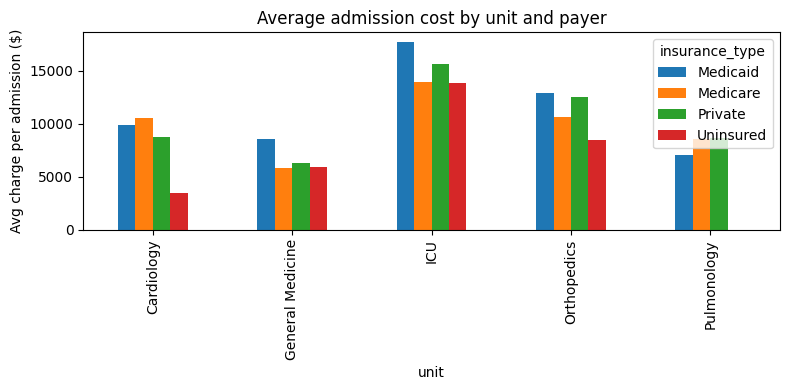

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
cost_pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Avg charge per admission ($)")
ax.set_title("Average admission cost by unit and payer")
plt.tight_layout()
plt.show()


In [50]:
# pivot_table with margins=True: grand totals baked in
los_pivot = enriched.pivot_table(values="los_days", index="unit", columns="insurance_type",
                                   aggfunc="mean", margins=True, margins_name="All")
los_pivot.round(2)


insurance_type,Medicaid,Medicare,Private,Uninsured,All
unit,,,,,
Cardiology,3.88,3.81,3.42,1.33,3.57
General Medicine,4.55,3.25,3.39,3.50,3.59
ICU,4.26,3.15,3.74,3.25,3.73
Orthopedics,3.75,3.22,3.68,2.67,3.48
Pulmonology,3.16,3.85,4.00,NaN,3.71
All,3.97,3.45,3.61,2.81,3.62


## 10. Vectorized String Operations  *(ref: 03.10)*

Discharge summaries are exactly the kind of messy, semi-structured text a
real EHR produces. We clean and mine them in bulk with `.str`.


In [51]:
discharge_notes["note_text"].head()


0      DC SUMMARY: A000218 / dx=Respiratory Failure...
1    DC SUMMARY: A000090 / dx=Post-Surgical Complic...
2    DC SUMMARY - A000238 / dx=COPD Exacerbation. p...
3      DC SUMMARY: A000170 / dx=Post-Surgical Compl...
4      DC SUMMARY - A000418 / dx=Pneumonia. patient...
Name: note_text, dtype: str

In [52]:
notes = discharge_notes.copy()

# Normalize whitespace/case for reliable parsing
notes["note_clean"] = notes["note_text"].str.strip().str.replace(r"\s+", " ", regex=True)

# Extract the diagnosis mentioned inline ("dx=...") with a vectorized regex
notes["dx_extracted"] = notes["note_clean"].str.extract(r"dx=([^.]+)\.")[0].str.strip()
notes[["admission_id", "dx_extracted"]].head()


,admission_id,dx_extracted
0,A000218,Respiratory Failure
1,A000090,Post-Surgical Complication
2,A000238,COPD Exacerbation
3,A000170,Post-Surgical Complication
4,A000418,Pneumonia


In [53]:
# Boolean string tests, vectorized across the whole column -- flag known
# care-transition risk factors mentioned in free text
risk_flags = {
    "flag_lives_alone_note":   r"living ALONE",
    "flag_non_compliant":      r"non-compliant",
    "flag_no_followup":        r"no primary care follow-up",
    "flag_polypharmacy":       r"polypharmacy",
    "flag_left_ama":           r"against medical advice|\bAMA\b",
    "flag_language_barrier":   r"language barrier",
    "flag_unstable_housing":   r"unstable housing",
}
for col, pattern in risk_flags.items():
    notes[col] = notes["note_clean"].str.contains(pattern, case=False, regex=True)

notes["n_risk_flags"] = notes[list(risk_flags)].sum(axis=1)
notes[["admission_id", "n_risk_flags"] + list(risk_flags)].head()


,admission_id,n_risk_flags,flag_lives_alone_note,flag_non_compliant,flag_no_followup,flag_polypharmacy,flag_left_ama,flag_language_barrier,flag_unstable_housing
0,A000218,1,False,False,False,True,False,False,False
1,A000090,0,False,False,False,False,False,False,False
2,A000238,2,True,False,False,False,False,True,False
3,A000170,0,False,False,False,False,False,False,False
4,A000418,0,False,False,False,False,False,False,False


In [54]:
# Chained string methods -- lower-case, strip punctuation, tokenize into a
# simple keyword list (lightweight text mining)
notes["keywords"] = (notes["note_clean"]
                       .str.lower()
                       .str.replace(r"[^a-z0-9\s]", "", regex=True)
                       .str.split())
notes[["admission_id", "keywords"]].head(3)


,admission_id,keywords
0,A000218,"[dc, summary, a000218, dxrespiratory, failure,..."
1,A000090,"[dc, summary, a000090, dxpostsurgical, complic..."
2,A000238,"[dc, summary, a000238, dxcopd, exacerbation, p..."


In [55]:
# Merge the parsed risk flags back onto the main table and check whether they
# actually correlate with cost/LOS -- string cleaning feeding straight into
# the analytics pipeline
enriched = enriched.merge(
    notes[["admission_id", "n_risk_flags"] + list(risk_flags)],
    on="admission_id", how="left",
)
enriched["n_risk_flags"] = enriched["n_risk_flags"].fillna(0)

enriched.groupby(enriched["n_risk_flags"] > 0)[["los_days", "total_charge_usd"]].mean().round(1)


,los_days,total_charge_usd
n_risk_flags,,
False,3.6,10796.5
True,3.6,10243.1


## 11. Working with Time Series  *(ref: 03.11)*

This is the heart of the notebook: we use `DatetimeIndex`-aware operations
to actually **compute the 30-day readmission outcome**, then use rolling
windows to build a simple bedside early-warning signal.


In [56]:
# --- Computing the 30-day readmission flag ---
# For each patient, sort their stays chronologically, then compare each
# admission's admit_date to the PREVIOUS stay's discharge_date using
# groupby + shift(). This is the actual real-world method for deriving
# the HRRP-style outcome from a raw ADT log.
readm = enriched.sort_values(["patient_id", "admit_date"]).copy()
readm["prev_discharge_date"] = readm.groupby("patient_id")["discharge_date"].shift(1)
readm["days_since_prior_discharge"] = (
    (readm["admit_date"] - readm["prev_discharge_date"]) / pd.Timedelta(days=1)
)
readm["is_30d_readmission"] = readm["days_since_prior_discharge"].between(0, 30)

overall_rate = readm["is_30d_readmission"].mean()
print(f"Overall 30-day readmission rate: {overall_rate:.1%}")
readm[["admission_id", "patient_id", "admit_date", "prev_discharge_date",
       "days_since_prior_discharge", "is_30d_readmission"]].head(8)


Overall 30-day readmission rate: 7.7%


,admission_id,patient_id,admit_date,prev_discharge_date,days_since_prior_discharge,is_30d_readmission
103,A000001,PT00001,2024-06-09,NaT,NaN,False
240,A000002,PT00004,2024-08-05,NaT,NaN,False
104,A000003,PT00006,2024-05-20,NaT,NaN,False
241,A000004,PT00006,2024-09-19,2024-05-25,117.0,False
0,A000005,PT00009,2024-03-24,NaT,NaN,False
105,A000006,PT00009,2024-06-17,2024-03-26,83.0,False
242,A000007,PT00009,2024-07-16,2024-06-21,25.0,True
243,A000008,PT00016,2024-07-08,NaT,NaN,False


In [57]:
# Readmission rate by unit and by diagnosis -- exactly what HRRP reporting
# and a quality-improvement committee need
by_unit = readm.groupby("unit")["is_30d_readmission"].agg(["mean", "count"]).rename(
    columns={"mean": "readmission_rate", "count": "n_admissions"})
by_unit["readmission_rate"] = (by_unit["readmission_rate"] * 100).round(1)
by_unit.sort_values("readmission_rate", ascending=False)


,readmission_rate,n_admissions
unit,,
General Medicine,14.0,100
Pulmonology,10.4,77
ICU,7.8,103
Orthopedics,3.2,93
Cardiology,2.5,79


In [58]:
# Does having a documented care-transition risk factor correlate with
# actually coming back within 30 days? (association only -- not causal)
readm.groupby(readm["n_risk_flags"] > 0)["is_30d_readmission"].mean().rename("readmission_rate").round(3)


n_risk_flags
False    0.077
True     0.078
Name: readmission_rate, dtype: float64

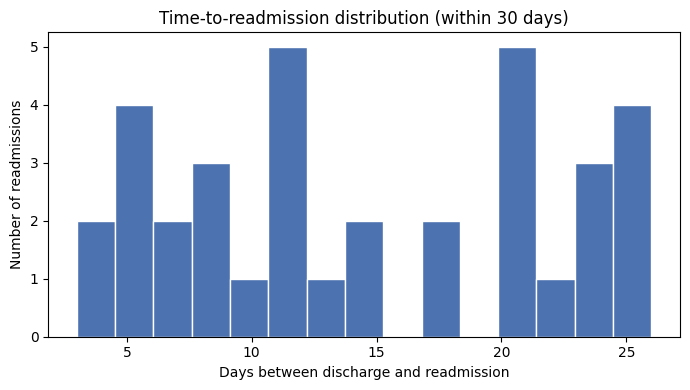

In [59]:
# Distribution of TIME TO READMISSION among true readmissions
gap_days = readm.loc[readm["is_30d_readmission"], "days_since_prior_discharge"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gap_days, bins=15, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Days between discharge and readmission")
ax.set_ylabel("Number of readmissions")
ax.set_title("Time-to-readmission distribution (within 30 days)")
plt.tight_layout()
plt.show()


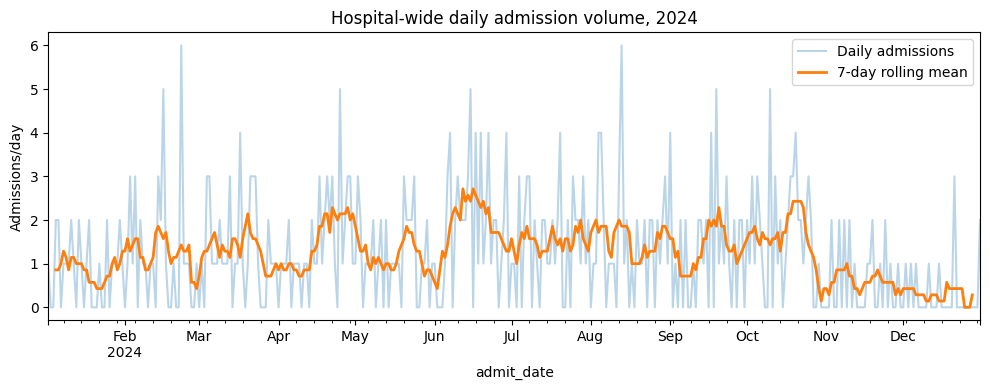

In [60]:
# resample() + rolling(): fleet-wide DAILY admission volume, smoothed with a
# 7-day rolling mean -- an operational capacity-planning view
daily_admits = (admissions.set_index("admit_date")
                 .resample("D")["admission_id"].count()
                 .rename("n_admissions"))
rolling_7d = daily_admits.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4))
daily_admits.plot(ax=ax, alpha=0.3, label="Daily admissions")
rolling_7d.plot(ax=ax, lw=2, label="7-day rolling mean")
ax.legend(); ax.set_ylabel("Admissions/day")
ax.set_title("Hospital-wide daily admission volume, 2024")
plt.tight_layout()
plt.show()


In [61]:
# Bedside EARLY-WARNING signal: rolling mean + rolling trend (via shift) of
# heart rate within a single monitored stay -- a simplified version of the
# kind of deterioration signal real early-warning-score systems compute
one_stay = vitals_filled[vitals_filled["admission_id"] == vitals_filled["admission_id"].iloc[0]]
one_stay = one_stay.set_index("timestamp").sort_index()

one_stay["hr_rolling_4h"] = one_stay["heart_rate"].rolling("4h").mean()
one_stay["hr_4h_ago"] = one_stay["heart_rate"].shift(4)
one_stay["hr_delta_4h"] = one_stay["heart_rate"] - one_stay["hr_4h_ago"]

one_stay[["heart_rate", "hr_rolling_4h", "hr_delta_4h"]].head(10)


,heart_rate,hr_rolling_4h,hr_delta_4h
timestamp,,,
2024-02-05 00:00:00,96.238652,96.238652,NaN
2024-02-05 01:00:00,94.057809,95.148230,NaN
2024-02-05 02:00:00,93.133213,94.476558,NaN
2024-02-05 03:00:00,95.662057,94.772933,NaN
2024-02-05 04:00:00,95.641380,94.623615,-0.597271
2024-02-05 05:00:00,88.689759,93.281602,-5.368050
2024-02-05 06:00:00,90.121579,92.528694,-3.011635
2024-02-05 07:00:00,96.655628,92.777086,0.993570
2024-02-05 08:00:00,100.550904,94.004467,4.909523


In [62]:
# Time zone handling: EHR timestamps are typically stored in UTC; clinical
# staff need to see LOCAL hospital time on any dashboard
utc_admits = admissions.set_index("admit_date")[["admission_id"]].copy()
utc_admits.index = utc_admits.index.tz_localize("UTC")
local_admits = utc_admits.tz_convert("America/Chicago")

print("UTC          :", utc_admits.index[0])
print("Local (CT)   :", local_admits.index[0])


UTC          : 2024-03-24 00:00:00+00:00
Local (CT)   : 2024-03-23 19:00:00-05:00


## 12. High-Performance Pandas — `eval()` and `query()`  *(ref: 03.12)*

`enriched` is a few thousand rows -- trivial for performance. But a real
health system's claims/charge-line-item table (one row per billed line item,
not per admission) easily reaches tens of millions of rows. We simulate that
scale to see why `eval()`/`query()` start to matter.


In [63]:
# Simulate a large CHARGE-LINE-ITEM table (multiple billed line items per
# admission), comparable in spirit to a real claims warehouse table
n = 3_000_000
big = pd.DataFrame({
    "unit_cost": rng.gamma(2.0, 120, n),
    "quantity": rng.integers(1, 6, n),
    "days_to_pay": rng.integers(1, 90, n),
})
big.shape


(3000000, 3)

In [64]:
import time

# --- Standard (temporary-array-heavy) computation ---
t0 = time.perf_counter()
result_std = big["unit_cost"] * big["quantity"] / big["days_to_pay"]
t_std = time.perf_counter() - t0

# --- pd.eval(): avoids allocating a full-size temporary for each sub-expression ---
t0 = time.perf_counter()
result_eval = pd.eval("big.unit_cost * big.quantity / big.days_to_pay")
t_eval = time.perf_counter() - t0

print(f"standard arithmetic: {t_std*1000:6.1f} ms")
print(f"pd.eval()          : {t_eval*1000:6.1f} ms")
print("results match:", np.allclose(result_std, result_eval))


standard arithmetic:   22.9 ms
pd.eval()          :   19.0 ms
results match: True


In [65]:
# DataFrame.eval(): compute AND assign a new column in one compact expression
big.eval("line_total = unit_cost * quantity", inplace=True)
big.head()


,unit_cost,quantity,days_to_pay,line_total
0,179.483945,3,62,538.451836
1,39.345545,5,21,196.727727
2,269.201973,3,82,807.605920
3,199.174016,3,55,597.522048
4,540.431569,2,64,1080.863138


In [66]:
# query() vs boolean masking -- both correct; query() reads like SQL and
# avoids materializing full intermediate boolean arrays for each condition
t0 = time.perf_counter()
mask_result = big[(big["line_total"] > 400) & (big["days_to_pay"] > 60)]
t_mask = time.perf_counter() - t0

t0 = time.perf_counter()
query_result = big.query("line_total > 400 and days_to_pay > 60")
t_query = time.perf_counter() - t0

print(f"boolean masking: {t_mask*1000:6.1f} ms  ({len(mask_result):,} rows)")
print(f"query()        : {t_query*1000:6.1f} ms  ({len(query_result):,} rows)")
print("results match:", mask_result.equals(query_result))


boolean masking:   86.6 ms  (587,068 rows)
query()        :  237.6 ms  (587,068 rows)
results match: True


As in the handbook, the win from `eval()`/`query()` comes mainly from
avoiding intermediate memory allocation rather than raw CPU speed — so it
matters most once a pipeline chains many derived columns and filters
together, exactly the shape of a real claims-line-item ETL job that runs
nightly against tens of millions of rows.


## 13. Wrap-up & Further Resources  *(ref: 03.13)*

### What we built and found
Starting from five independent, messy raw sources, we built `enriched`/`readm`:
a single merged, time-aware table linking admissions, demographics, labs,
billing, and parsed discharge-note risk factors — and used it to **derive the
30-day readmission outcome itself** from raw admit/discharge dates, then rank
where the risk concentrates:

- An overall 30-day readmission rate, broken out **by unit and diagnosis**
- A first-pass association between **discharge-note risk factors**
  (living alone, no follow-up scheduled, polypharmacy, etc.) and return visits
- **Cost and length-of-stay** patterns by unit and payer
- A simple **bedside early-warning** rolling-trend signal from vitals telemetry
- A time-to-readmission distribution showing *when* return visits cluster

### Techniques applied, chapter by chapter
| Chapter | Technique | Where we used it |
|---|---|---|
| 3.01 | Series / DataFrame / Index | Building `patients`, `chronic_burden` |
| 3.02 | `loc` / `iloc` / boolean masks | Cohort selection, long ICU stays |
| 3.03 | Ufuncs & index alignment | Combining internal + vendor risk scores |
| 3.04 | Missing data | Interpolating vitals, median-filling labs |
| 3.05 | MultiIndex | `(unit, admission_id, timestamp)` vitals panel |
| 3.06 | `concat` | Stitching 4 quarterly ADT extracts into a year |
| 3.07 | `merge` / `join` | Enriching admissions with demographics, billing, labs |
| 3.08 | `groupby` / `transform` / `filter` | LOS outliers, reportable diagnosis volume |
| 3.09 | `pivot_table` | Monthly volume, cost by unit x payer |
| 3.10 | `.str` accessor | Mining discharge-note risk factors |
| 3.11 | Time series (`shift`, `resample`, `rolling`, tz) | **Deriving the readmission outcome**, early-warning trend |
| 3.12 | `eval()` / `query()` | Scaling to a multi-million-row claims line-item table |

### Important caveats
- All data here is **synthetic**; no real patient information was used or
  is represented.
- Nothing in this notebook is a validated clinical or predictive model —
  the association shown between risk-factor text and readmission is
  illustrative, not causal, and would need proper statistical validation
  (e.g. logistic regression with confounder adjustment) before informing
  any real care decision.
- Any real version of this pipeline must be built and hosted in a
  HIPAA-compliant environment with appropriate governance and de-identification.

### Where to go next
- Feed the cleaned `readm` table into a proper predictive model
  (e.g. `scikit-learn` logistic regression or gradient boosting) to predict
  readmission risk *at the time of discharge*, not just describe it after the fact.
- Compare the derived rate against CMS's published HRRP methodology and
  excess-readmission-ratio definitions for an apples-to-apples benchmark.
- Extend the vitals early-warning signal into a proper composite score
  (e.g. a NEWS2-style aggregate) computed continuously with `rolling()`.
- As the handbook's closing chapter notes, the official Pandas documentation
  (https://pandas.pydata.org/docs/) is the best reference for going deeper
  on any single method used here, and `Dask` is the natural next step once
  the real claims/EHR extracts outgrow a single machine's memory.
